# Explore correlations for Arctic Ocean domain

In [16]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import warnings
import s3fs
import gsw
import time

In [2]:
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [3]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:45861")
client

<Client: 'tcp://127.0.0.1:45861' processes=8 threads=32, memory=123.95 GiB>

### Open ocean mask

In [4]:
# open Arctic ocean mak
arctic_ocean_mask = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/Arctic_domain_mask/arctic_domain_mask.nc")

In [5]:
# select variable
ocean_mask = arctic_ocean_mask.arctic_ocean_mask

### Open datasets

In [6]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [7]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [8]:
# open SALT zarr store - [psu]
SALT_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

In [6]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [7]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

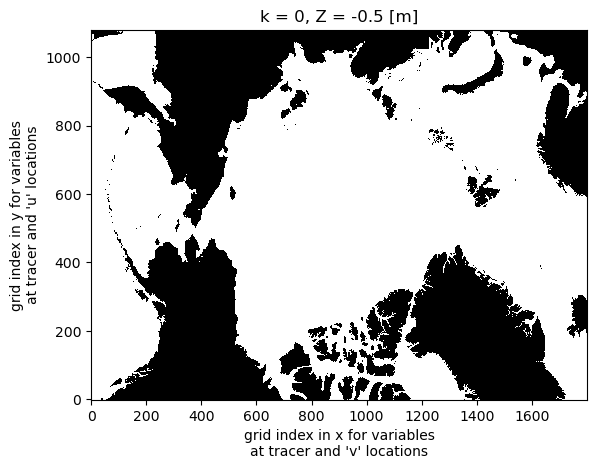

In [11]:
HH_grid_land.plot(vmin=-1,vmax=0,cmap='Grays',add_colorbar=False);

### Apply Arctic ocean domain mask

In [12]:
# isolate arctic ocean
salt_Arctic = SALT_zarr.SALT.where(HH_grid.mask_basin==1).where(ocean_mask)
theta_Arctic = THETA_zarr.THETA.where(HH_grid.mask_basin==1).where(ocean_mask)

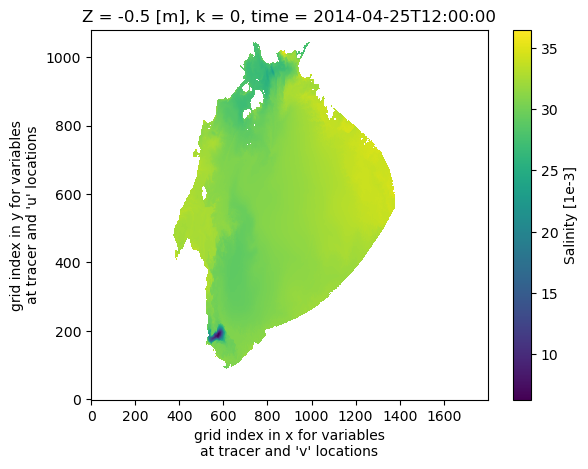

In [13]:
# double check
salt_Arctic.isel(time=100,k=0).plot();

### Calculate monthly mean for August

In [14]:
# filter only August data
salt_august = salt_Arctic.sel(time=salt_Arctic["time"].dt.month == 8)
theta_august = theta_Arctic.sel(time=theta_Arctic["time"].dt.month == 8)

# group by year and calculate mean for August
salt_august_avg = salt_august.groupby("time.year").mean(dim="time")
theta_august_avg = theta_august.groupby("time.year").mean(dim="time")

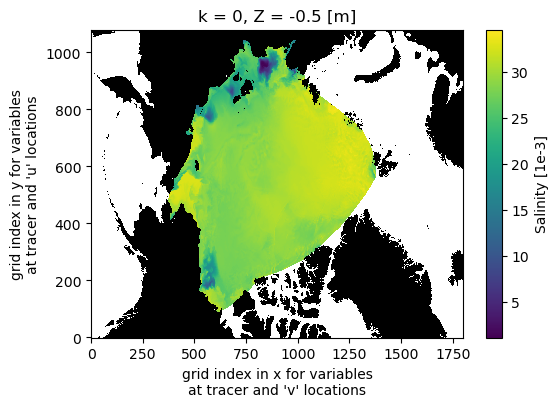

In [15]:
# take a look at surface salinity for one month
salt_august.isel(time=3,k=0).plot(figsize=[6,4]);
HH_grid_land.plot(vmin=-1,vmax=0,cmap='Grays',add_colorbar=False);

### Save August SSS means

In [50]:
salt_august_avg.to_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_AUGUST_MEAN_SALT.ZARR")
theta_august_avg.to_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_AUGUST_MEAN_THETA.ZARR")

### Open August means and density

In [51]:
salt_august_avg = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_AUGUST_MEAN_SALT.ZARR")
theta_august_avg = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_AUGUST_MEAN_THETA.ZARR")

### Calculate potential density

In [53]:
# select only vertical levels we want (surface, 20, and 100 m)
salt_levels = salt_august_avg.SALT.isel(k=[0,10,21])
theta_levels = theta_august_avg.THETA.isel(k=[0,10,21])

In [54]:
salt_levels.Z.values

array([ -0.5  , -21.125, -99.37 ], dtype=float32)

In [55]:
# pressure from depth
# Z needs to be positive up
pressure_da = gsw.p_from_z(HH_grid.isel(k=[0,10,21]).Z, HH_grid.YC).compute()

In [56]:
# just double check to make sure they look reasonable
pressure_da.isel(i=10,j=10).values

array([  0.50428623,  21.30716931, 100.246103  ])

In [57]:
# Calculates Absolute Salinity from Practical Salinity
salt_august_levels = gsw.SA_from_SP(salt_levels, pressure_da, HH_grid.XC, HH_grid.YC)

In [58]:
# Calculates Conservative Temperature of seawater from potential temperature (whose reference sea pressure is zero dbar)
temp_august_levels = gsw.CT_from_pt(salt_august_levels, theta_levels)

In [59]:
# calculate potential density
sigma_august_levels = gsw.density.sigma0(salt_august_levels, temp_august_levels)

# change name and clear salinity attrs
sigma_august_levels.name = 'potential_density'
sigma_august_levels.attrs = ""

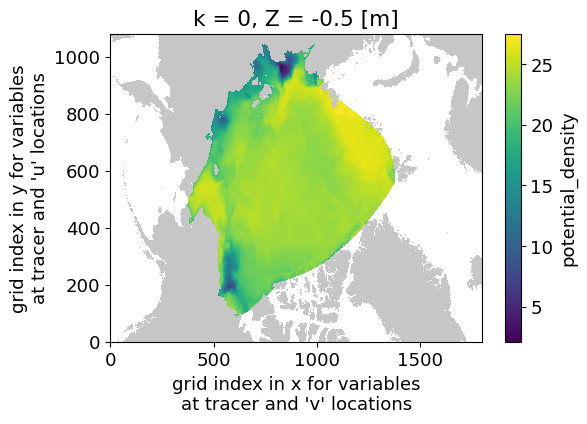

In [60]:
# take a look at density for sanity check
sigma_august_levels.isel(year=3,k=0).plot(figsize=[6,4]);
HH_grid_land.plot(vmin=-1,vmax=2,cmap='Greys',add_colorbar=False);

### Save August potential density means for 0, 20, 100 m

In [61]:
sigma_august_levels.to_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_AUGUST_MEAN_DENSITY.ZARR")

## Open August means

In [8]:
salt_august_avg = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_AUGUST_MEAN_SALT.ZARR")
theta_august_avg = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_AUGUST_MEAN_THETA.ZARR")
sigma_august_levels = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_AUGUST_MEAN_DENSITY.ZARR")

In [10]:
salt_august_avg = salt_august_avg.SALT
theta_august_avg = theta_august_avg.THETA
sigma_august_levels = sigma_august_levels.potential_density

## Plot August means

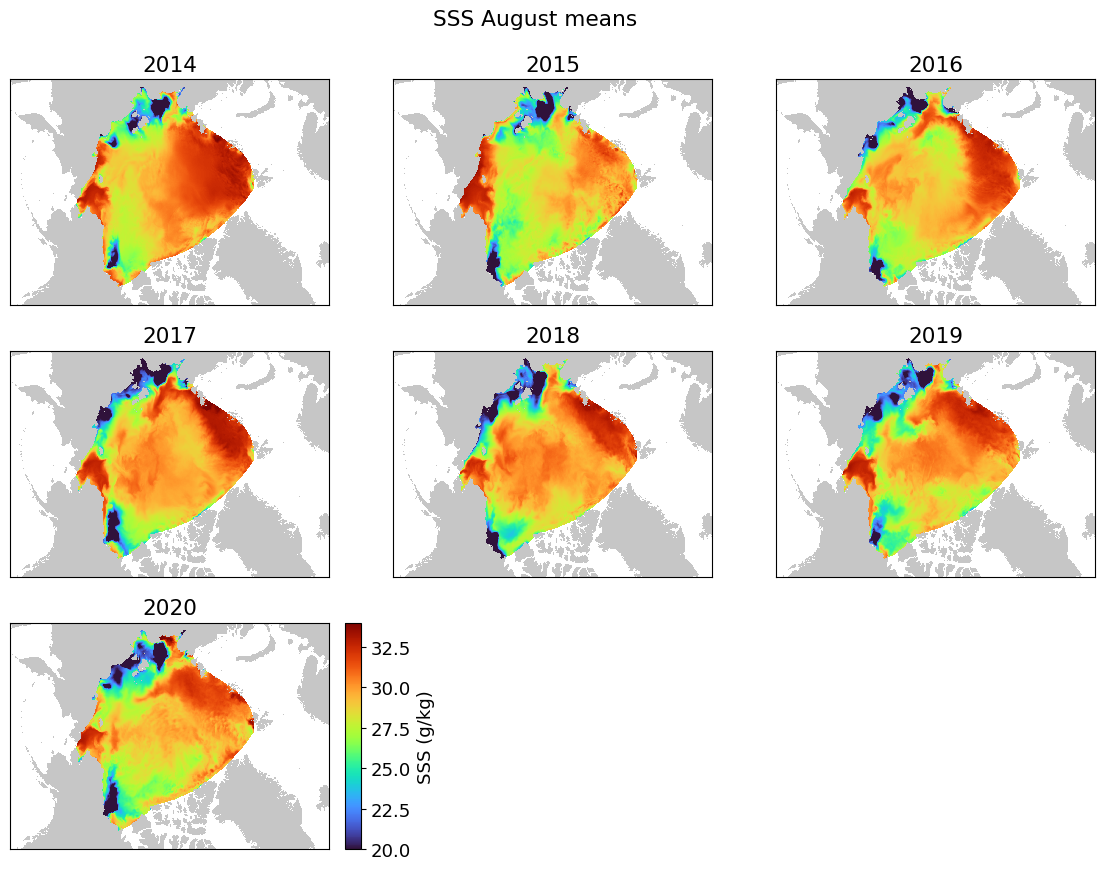

In [35]:
plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3,3,figsize=[14,10])

# plot august means
salt_august_avg.isel(year=0,k=0).plot(ax=ax1, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_avg.isel(year=1,k=0).plot(ax=ax2, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_avg.isel(year=2,k=0).plot(ax=ax3, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_avg.isel(year=3,k=0).plot(ax=ax4, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_avg.isel(year=4,k=0).plot(ax=ax5, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_avg.isel(year=5,k=0).plot(ax=ax6, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
cbar = salt_august_avg.isel(year=6,k=0).plot(ax=ax7, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);

for ax in (ax1,ax2,ax3,ax4,ax5,ax6,ax7):
    HH_grid_land.plot(ax=ax,vmin=-1,vmax=2,cmap='Grays',add_colorbar=False);
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Turn off the axes we don't need
ax8.set_axis_off()
ax9.set_axis_off()

# titles
ax1.set_title(str(salt_august_avg.isel(year=0).year.values))
ax2.set_title(str(salt_august_avg.isel(year=1).year.values))
ax3.set_title(str(salt_august_avg.isel(year=2).year.values))
ax4.set_title(str(salt_august_avg.isel(year=3).year.values))
ax5.set_title(str(salt_august_avg.isel(year=4).year.values))
ax6.set_title(str(salt_august_avg.isel(year=5).year.values))
ax7.set_title(str(salt_august_avg.isel(year=6).year.values))

# Make a colorbar
cax = ax7.inset_axes([1.05, 0, 0.05, 1])
cbar = fig.colorbar(cbar,cax=cax)
cbar.ax.set_ylabel('SSS (g/kg)');

plt.suptitle("SSS August means", y=0.95);

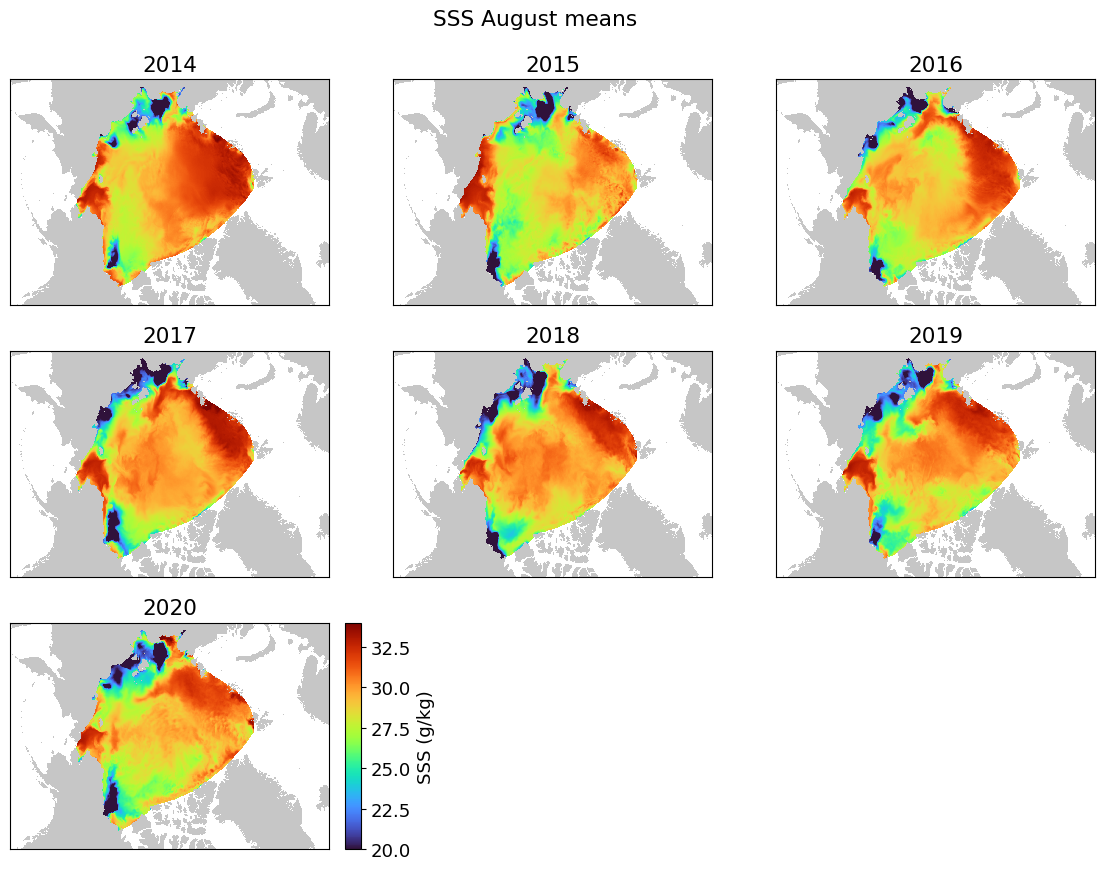

In [35]:
plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3,3,figsize=[14,10])

# plot august means
salt_august_levels.isel(year=0,k=0).plot(ax=ax1, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_levels.isel(year=1,k=0).plot(ax=ax2, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_levels.isel(year=2,k=0).plot(ax=ax3, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_levels.isel(year=3,k=0).plot(ax=ax4, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_levels.isel(year=4,k=0).plot(ax=ax5, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
salt_august_levels.isel(year=5,k=0).plot(ax=ax6, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);
cbar = salt_august_levels.isel(year=6,k=0).plot(ax=ax7, vmin=20,vmax=34,cmap='turbo',add_colorbar=False);

for ax in (ax1,ax2,ax3,ax4,ax5,ax6,ax7):
    HH_grid_land.plot(ax=ax,vmin=-1,vmax=2,cmap='Grays',add_colorbar=False);
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Turn off the axes we don't need
ax8.set_axis_off()
ax9.set_axis_off()

# titles
ax1.set_title(str(salt_august_levels.isel(year=0).year.values))
ax2.set_title(str(salt_august_levels.isel(year=1).year.values))
ax3.set_title(str(salt_august_levels.isel(year=2).year.values))
ax4.set_title(str(salt_august_levels.isel(year=3).year.values))
ax5.set_title(str(salt_august_levels.isel(year=4).year.values))
ax6.set_title(str(salt_august_levels.isel(year=5).year.values))
ax7.set_title(str(salt_august_levels.isel(year=6).year.values))

# Make a colorbar
cax = ax7.inset_axes([1.05, 0, 0.05, 1])
cbar = fig.colorbar(cbar,cax=cax)
cbar.ax.set_ylabel('SSS (g/kg)');

plt.suptitle("SSS August means", y=0.95);

## Plot delta rho (20 m)

In [11]:
# calculate potential density difference

# between surface and 20 m
delta_sigma_20m = sigma_august_levels.isel(k=0) - sigma_august_levels.isel(k=1)

# between surface and 100 m
delta_sigma_100m = sigma_august_levels.isel(k=0) - sigma_august_levels.isel(k=2)

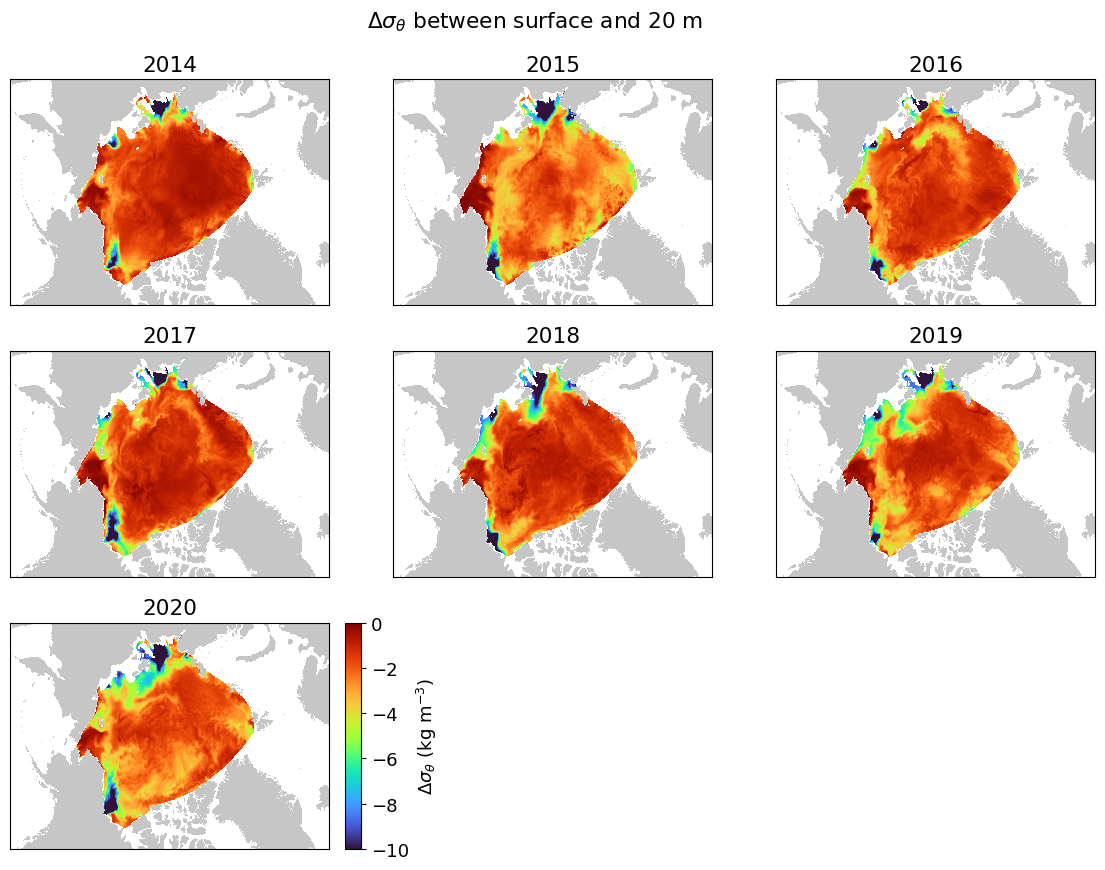

In [43]:
plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3,3,figsize=[14,10])

# plot august means
delta_sigma_20m.isel(year=0).plot(ax=ax1, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_20m.isel(year=1).plot(ax=ax2, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_20m.isel(year=2).plot(ax=ax3, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_20m.isel(year=3).plot(ax=ax4, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_20m.isel(year=4).plot(ax=ax5, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_20m.isel(year=5).plot(ax=ax6, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
cbar = delta_sigma_20m.isel(year=6).plot(ax=ax7, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);

for ax in (ax1,ax2,ax3,ax4,ax5,ax6,ax7):
    HH_grid_land.plot(ax=ax,vmin=-1,vmax=2,cmap='Grays',add_colorbar=False);
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Turn off the axes we don't need
ax8.set_axis_off()
ax9.set_axis_off()

# titles
ax1.set_title(str(delta_sigma_20m.isel(year=0).year.values))
ax2.set_title(str(delta_sigma_20m.isel(year=1).year.values))
ax3.set_title(str(delta_sigma_20m.isel(year=2).year.values))
ax4.set_title(str(delta_sigma_20m.isel(year=3).year.values))
ax5.set_title(str(delta_sigma_20m.isel(year=4).year.values))
ax6.set_title(str(delta_sigma_20m.isel(year=5).year.values))
ax7.set_title(str(delta_sigma_20m.isel(year=6).year.values))

# Make a colorbar
cax = ax7.inset_axes([1.05, 0, 0.05, 1])
cbar = fig.colorbar(cbar,cax=cax)
cbar.ax.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)');

plt.suptitle(r'$\Delta \sigma_{\theta}$ between surface and 20 m', y=0.95);

## Plot delta rho (100 m)

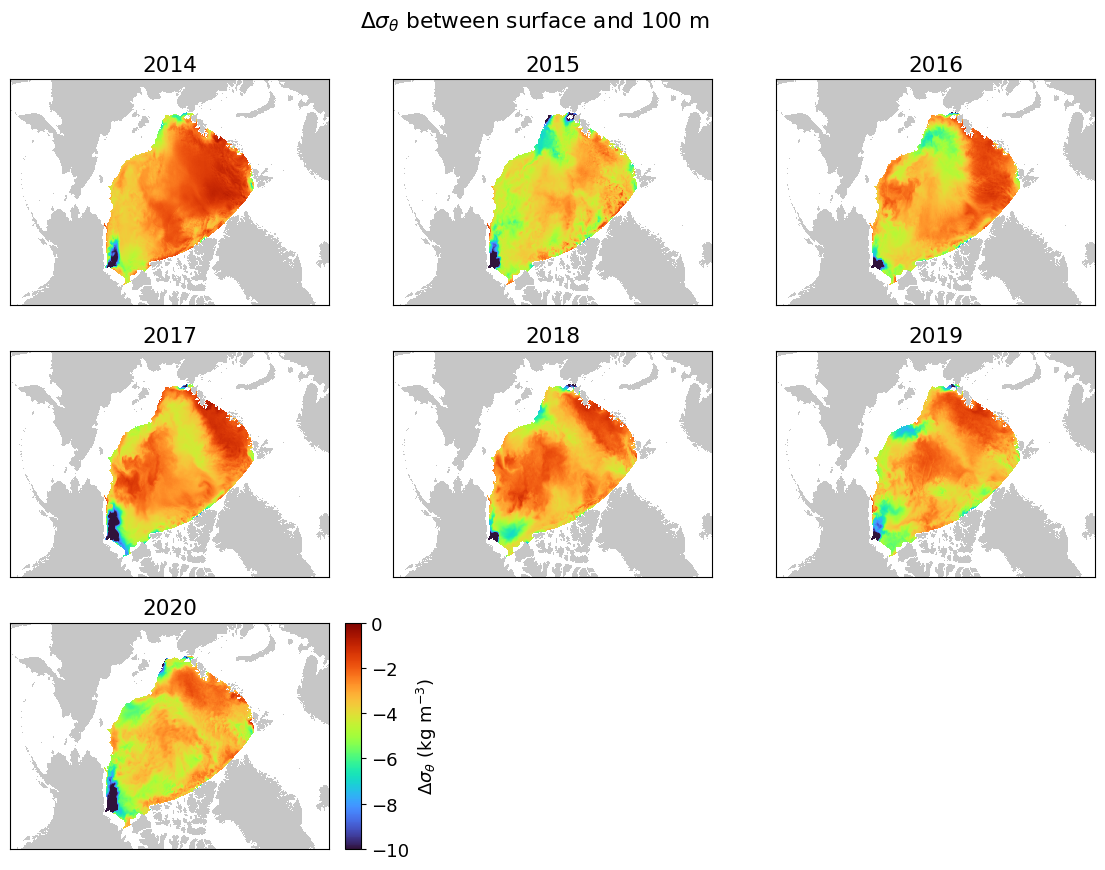

In [44]:
plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3,3,figsize=[14,10])

# plot august means
delta_sigma_100m.isel(year=0).plot(ax=ax1, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_100m.isel(year=1).plot(ax=ax2, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_100m.isel(year=2).plot(ax=ax3, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_100m.isel(year=3).plot(ax=ax4, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_100m.isel(year=4).plot(ax=ax5, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
delta_sigma_100m.isel(year=5).plot(ax=ax6, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);
cbar = delta_sigma_100m.isel(year=6).plot(ax=ax7, vmin=-10,vmax=0,cmap='turbo',add_colorbar=False);

for ax in (ax1,ax2,ax3,ax4,ax5,ax6,ax7):
    HH_grid_land.plot(ax=ax,vmin=-1,vmax=2,cmap='Grays',add_colorbar=False);
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Turn off the axes we don't need
ax8.set_axis_off()
ax9.set_axis_off()

# titles
ax1.set_title(str(delta_sigma_100m.isel(year=0).year.values))
ax2.set_title(str(delta_sigma_100m.isel(year=1).year.values))
ax3.set_title(str(delta_sigma_100m.isel(year=2).year.values))
ax4.set_title(str(delta_sigma_100m.isel(year=3).year.values))
ax5.set_title(str(delta_sigma_100m.isel(year=4).year.values))
ax6.set_title(str(delta_sigma_100m.isel(year=5).year.values))
ax7.set_title(str(delta_sigma_100m.isel(year=6).year.values))

# Make a colorbar
cax = ax7.inset_axes([1.05, 0, 0.05, 1])
cbar = fig.colorbar(cbar,cax=cax)
cbar.ax.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)');

plt.suptitle(r'$\Delta \sigma_{\theta}$ between surface and 100 m', y=0.95);

## Make scatter plots

### Scatter plots of $\Delta \sigma$ over upper 20m vs SSS and S(20m)

Delta rho in upper 20 m vs. SSS

Time taken to plot: 0.1274 minutes


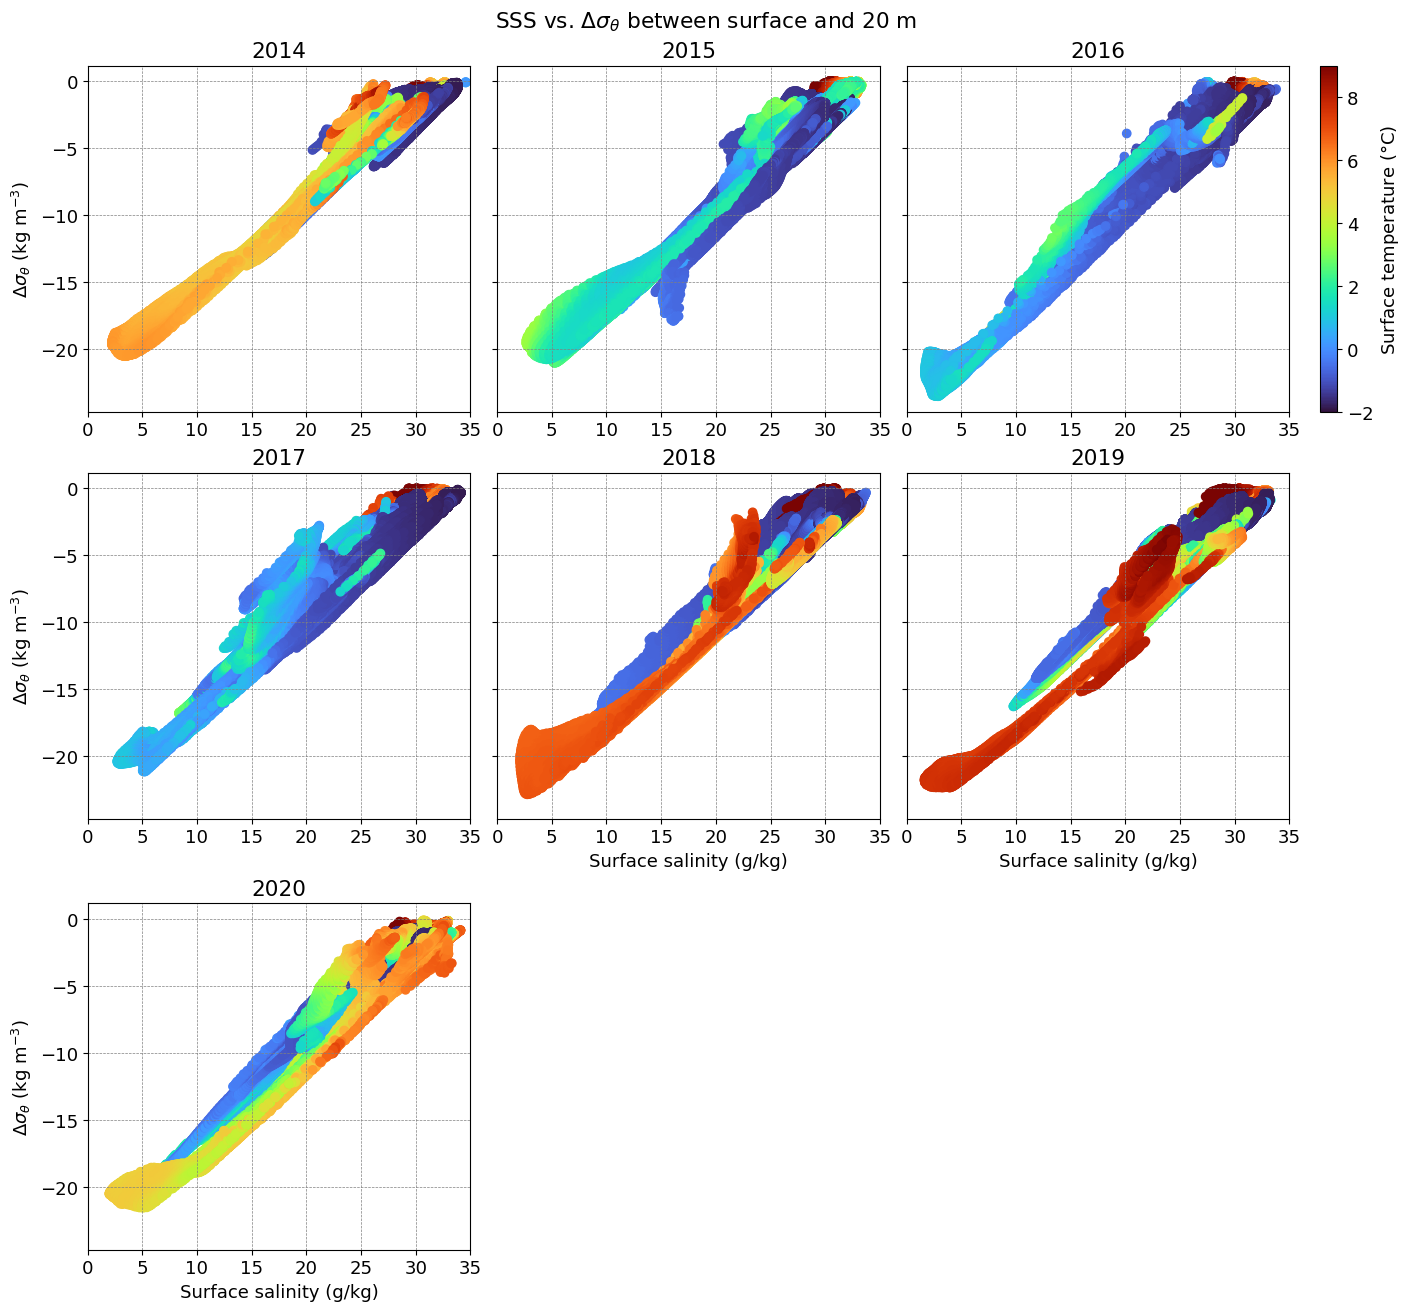

In [30]:
# Measure the time taken to plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3,3,figsize=[14,13], sharey=True, layout='constrained')

# difference in density between surface and 20 m (surf-20)
ax1.scatter(salt_august_avg.isel(k=0,year=0),delta_sigma_20m.isel(year=0),\
            c=theta_august_avg.isel(k=0,year=0),cmap='turbo',vmin=-2,vmax=9);

ax2.scatter(salt_august_avg.isel(k=0,year=1),delta_sigma_20m.isel(year=1),\
            c=theta_august_avg.isel(k=0,year=1),cmap='turbo',vmin=-2,vmax=9);

cbar_temp = ax3.scatter(salt_august_avg.isel(k=0,year=2),delta_sigma_20m.isel(year=2),\
                        c=theta_august_avg.isel(k=0,year=2),cmap='turbo',vmin=-2,vmax=9);

ax4.scatter(salt_august_avg.isel(k=0,year=3),delta_sigma_20m.isel(year=3),\
            c=theta_august_avg.isel(k=0,year=3),cmap='turbo',vmin=-2,vmax=9);

ax5.scatter(salt_august_avg.isel(k=0,year=4),delta_sigma_20m.isel(year=4),\
            c=theta_august_avg.isel(k=0,year=4),cmap='turbo',vmin=-2,vmax=9);

ax6.scatter(salt_august_avg.isel(k=0,year=5),delta_sigma_20m.isel(year=5),\
            c=theta_august_avg.isel(k=0,year=5),cmap='turbo',vmin=-2,vmax=9);

ax7.scatter(salt_august_avg.isel(k=0,year=6),delta_sigma_20m.isel(year=6),\
            c=theta_august_avg.isel(k=0,year=6),cmap='turbo',vmin=-2,vmax=9);

ax1.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax4.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax7.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax3)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

for ax in (ax1,ax2,ax3,ax4,ax5,ax6,ax7):
    ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
    ax.set_xlim(0,35)
    ax.set_xlabel("")

ax7.set_xlabel("Surface salinity (g/kg)")
ax5.set_xlabel("Surface salinity (g/kg)")
ax6.set_xlabel("Surface salinity (g/kg)")
    
# Turn off the axes we don't need
ax8.set_axis_off()
ax9.set_axis_off()

# titles
ax1.set_title(str(salt_august_avg.isel(year=0).year.values))
ax2.set_title(str(salt_august_avg.isel(year=1).year.values))
ax3.set_title(str(salt_august_avg.isel(year=2).year.values))
ax4.set_title(str(salt_august_avg.isel(year=3).year.values))
ax5.set_title(str(salt_august_avg.isel(year=4).year.values))
ax6.set_title(str(salt_august_avg.isel(year=5).year.values))
ax7.set_title(str(salt_august_avg.isel(year=6).year.values))

plt.suptitle(r'SSS vs. $\Delta \sigma_{\theta}$ between surface and 20 m');

end_time = time.time()  # End timer

# Compute and display elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")

Time taken to plot: 0.0760 minutes


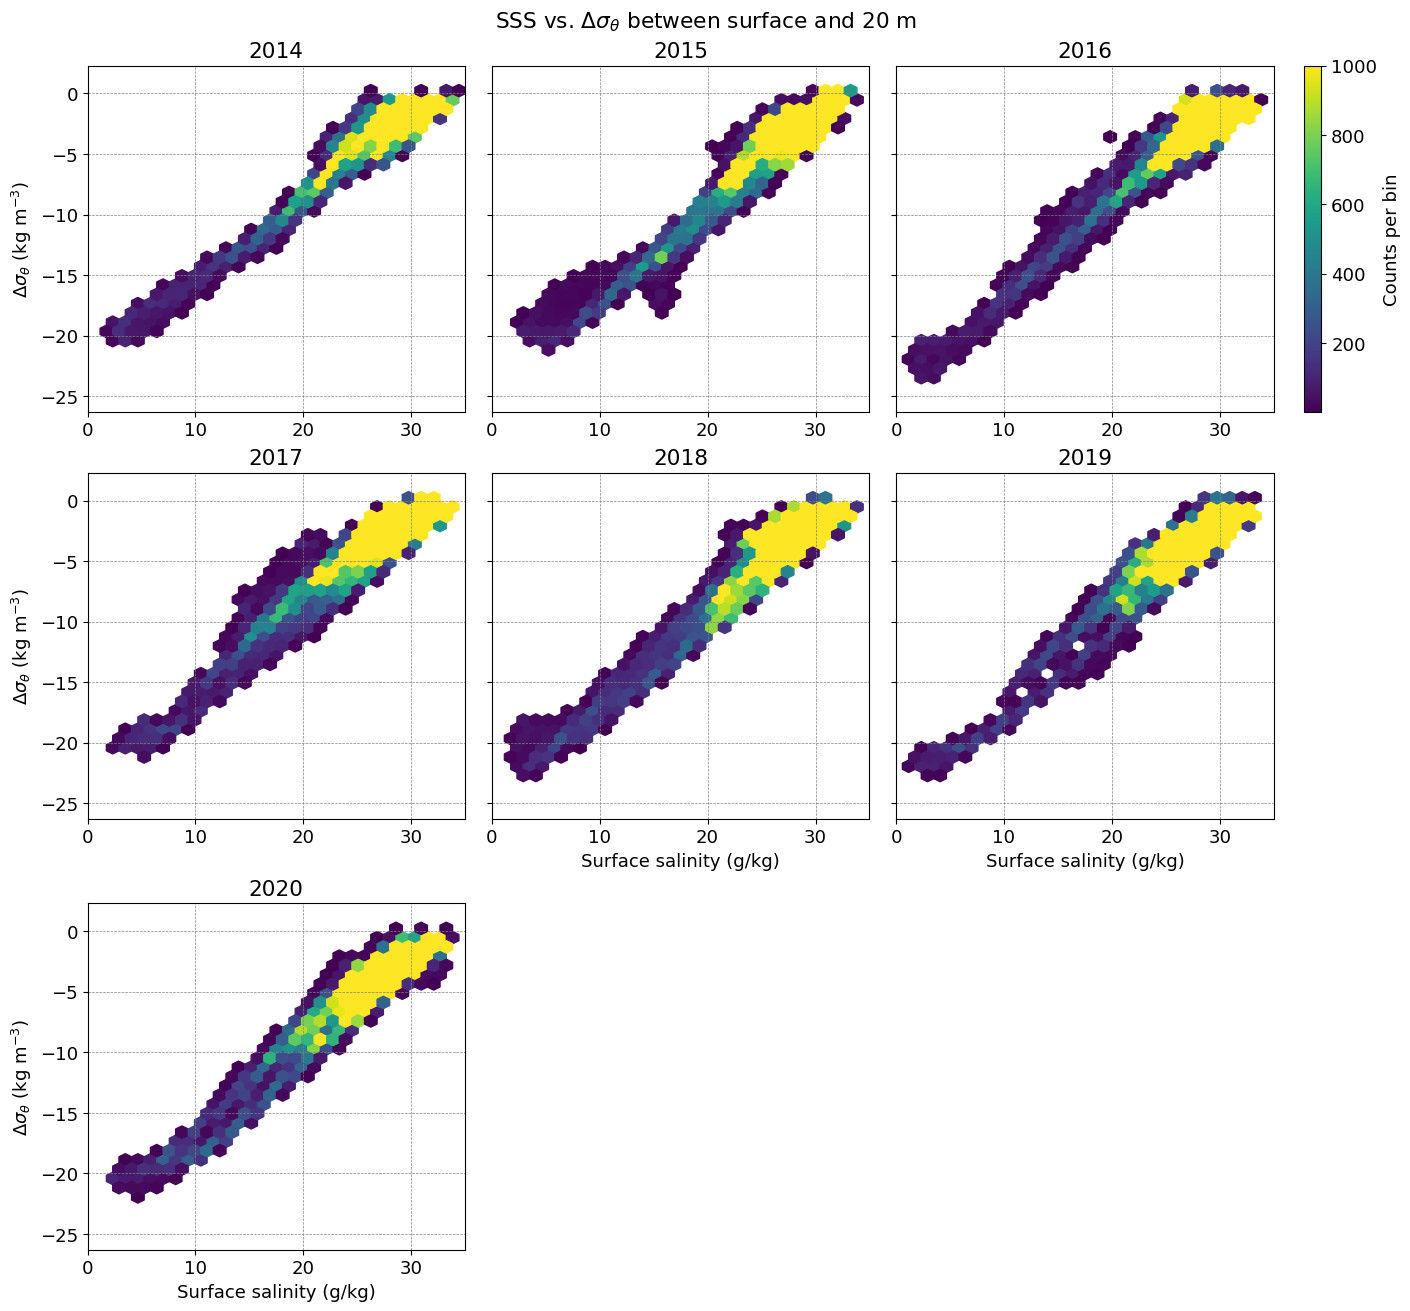

In [31]:
# Measure the time taken to plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3,3,figsize=[14,13], sharey=True, layout='constrained')

# difference in density between surface and 20 m (surf-20)
extent = [0,35,-25,1]

ax1.hexbin(salt_august_avg.isel(k=0,year=0),delta_sigma_20m.isel(year=0), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax2.hexbin(salt_august_avg.isel(k=0,year=1),delta_sigma_20m.isel(year=1), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
cbar_num = ax3.hexbin(salt_august_avg.isel(k=0,year=2),delta_sigma_20m.isel(year=2), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax4.hexbin(salt_august_avg.isel(k=0,year=3),delta_sigma_20m.isel(year=3), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax5.hexbin(salt_august_avg.isel(k=0,year=4),delta_sigma_20m.isel(year=4), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax6.hexbin(salt_august_avg.isel(k=0,year=5),delta_sigma_20m.isel(year=5), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax7.hexbin(salt_august_avg.isel(k=0,year=6),delta_sigma_20m.isel(year=6), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)

ax1.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax4.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax7.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_num,ax=ax3)
cbar.ax.set_ylabel('Counts per bin');

for ax in (ax1,ax2,ax3,ax4,ax5,ax6,ax7):
    ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
    ax.set_xlim(0,35)
    ax.set_xlabel("")

ax7.set_xlabel("Surface salinity (g/kg)")
ax5.set_xlabel("Surface salinity (g/kg)")
ax6.set_xlabel("Surface salinity (g/kg)")
    
# Turn off the axes we don't need
ax8.set_axis_off()
ax9.set_axis_off()

# titles
ax1.set_title(str(salt_august_avg.isel(year=0).year.values))
ax2.set_title(str(salt_august_avg.isel(year=1).year.values))
ax3.set_title(str(salt_august_avg.isel(year=2).year.values))
ax4.set_title(str(salt_august_avg.isel(year=3).year.values))
ax5.set_title(str(salt_august_avg.isel(year=4).year.values))
ax6.set_title(str(salt_august_avg.isel(year=5).year.values))
ax7.set_title(str(salt_august_avg.isel(year=6).year.values))

plt.suptitle(r'SSS vs. $\Delta \sigma_{\theta}$ between surface and 20 m');

end_time = time.time()  # End timer

# Compute and display elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")

Delta rho in upper 20 m vs. S(20 m)

In [14]:
salt_august_avg.isel(k=10).Z.values

array(-21.125, dtype=float32)

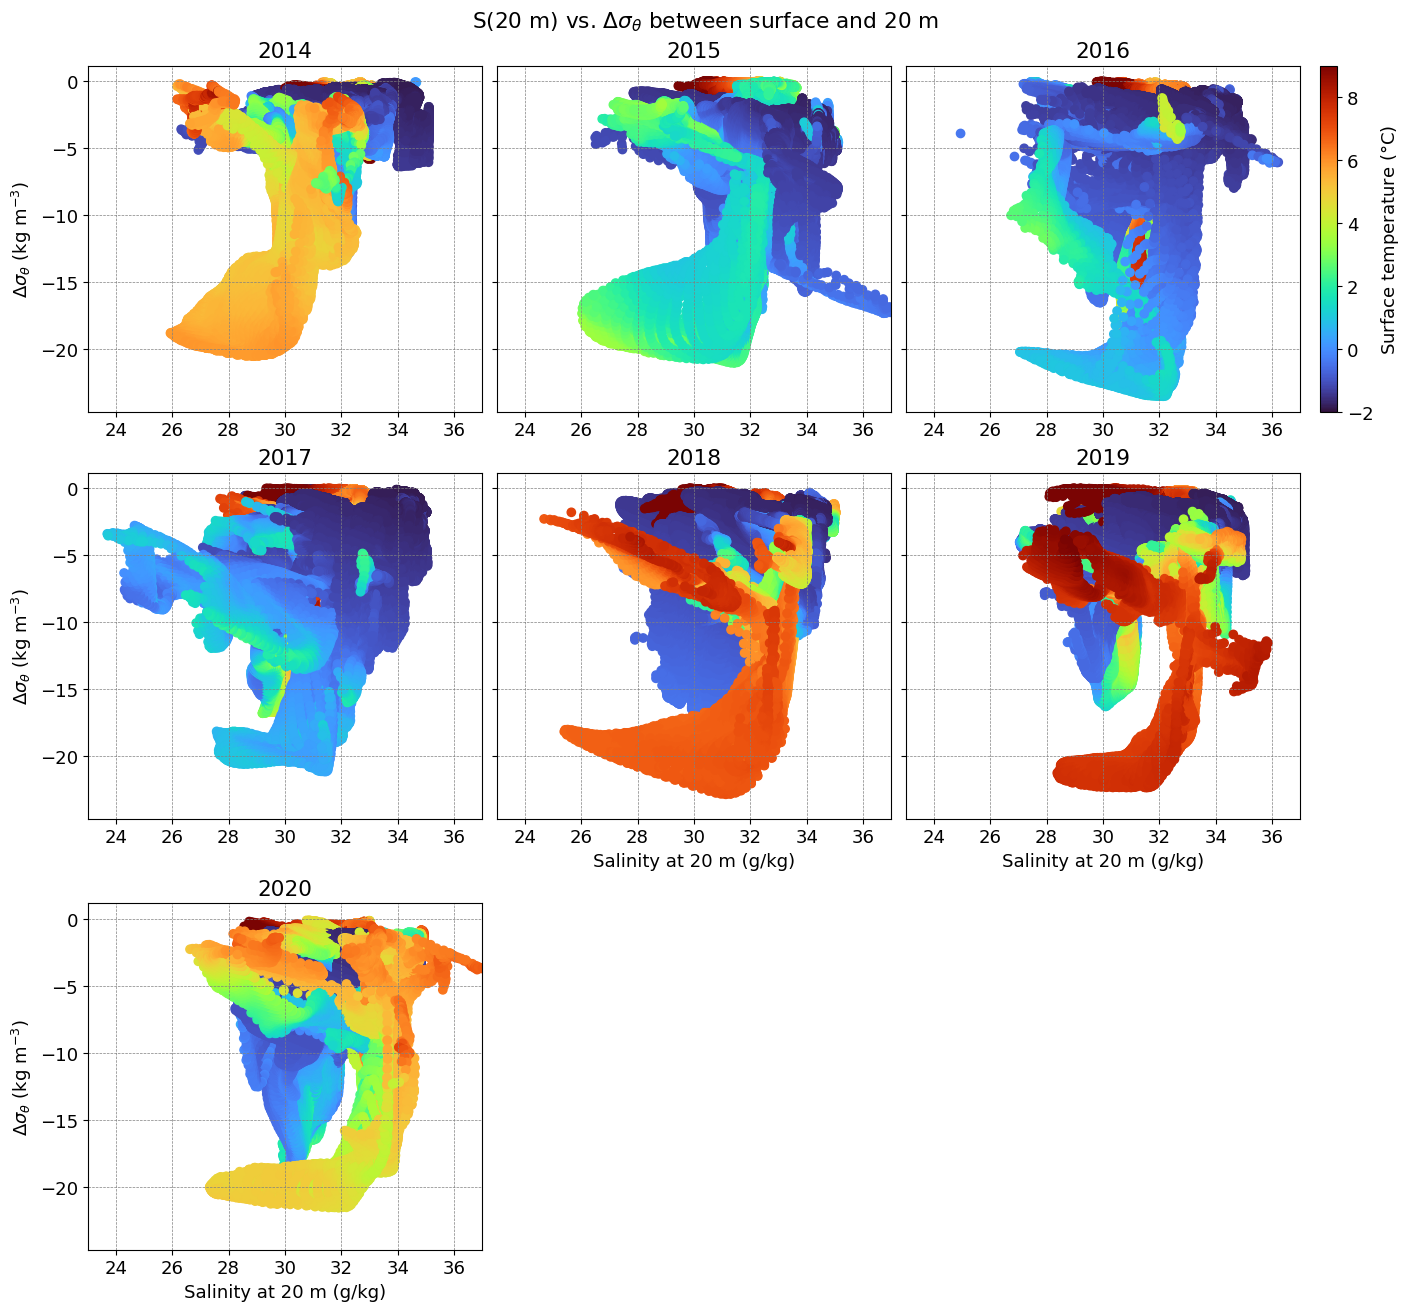

Time taken to plot: 0.1281 minutes


In [33]:
# Measure the time taken to plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3,3,figsize=[14,13], sharey=True, layout='constrained')

# difference in density between surface and 20 m (surf-20)
ax1.scatter(salt_august_avg.isel(k=10,year=0),delta_sigma_20m.isel(year=0),\
            c=theta_august_avg.isel(k=0,year=0),cmap='turbo',vmin=-2,vmax=9);

ax2.scatter(salt_august_avg.isel(k=10,year=1),delta_sigma_20m.isel(year=1),\
            c=theta_august_avg.isel(k=0,year=1),cmap='turbo',vmin=-2,vmax=9);

cbar_temp = ax3.scatter(salt_august_avg.isel(k=10,year=2),delta_sigma_20m.isel(year=2),\
                        c=theta_august_avg.isel(k=0,year=2),cmap='turbo',vmin=-2,vmax=9);

ax4.scatter(salt_august_avg.isel(k=10,year=3),delta_sigma_20m.isel(year=3),\
            c=theta_august_avg.isel(k=0,year=3),cmap='turbo',vmin=-2,vmax=9);

ax5.scatter(salt_august_avg.isel(k=10,year=4),delta_sigma_20m.isel(year=4),\
            c=theta_august_avg.isel(k=0,year=4),cmap='turbo',vmin=-2,vmax=9);

ax6.scatter(salt_august_avg.isel(k=10,year=5),delta_sigma_20m.isel(year=5),\
            c=theta_august_avg.isel(k=0,year=5),cmap='turbo',vmin=-2,vmax=9);

ax7.scatter(salt_august_avg.isel(k=10,year=6),delta_sigma_20m.isel(year=6),\
            c=theta_august_avg.isel(k=0,year=6),cmap='turbo',vmin=-2,vmax=9);

ax1.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax4.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax7.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax3)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

for ax in (ax1,ax2,ax3,ax4,ax5,ax6,ax7):
    ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
    ax.set_xlim(23,37)
    ax.set_xlabel("")

ax7.set_xlabel("Salinity at 20 m (g/kg)")
ax5.set_xlabel("Salinity at 20 m (g/kg)")
ax6.set_xlabel("Salinity at 20 m (g/kg)")
    
# Turn off the axes we don't need
ax8.set_axis_off()
ax9.set_axis_off()

# titles
ax1.set_title(str(salt_august_avg.isel(year=0).year.values))
ax2.set_title(str(salt_august_avg.isel(year=1).year.values))
ax3.set_title(str(salt_august_avg.isel(year=2).year.values))
ax4.set_title(str(salt_august_avg.isel(year=3).year.values))
ax5.set_title(str(salt_august_avg.isel(year=4).year.values))
ax6.set_title(str(salt_august_avg.isel(year=5).year.values))
ax7.set_title(str(salt_august_avg.isel(year=6).year.values))

plt.suptitle(r'S(20 m) vs. $\Delta \sigma_{\theta}$ between surface and 20 m');

end_time = time.time()  # End timer

plt.show()

# Compute and display elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")

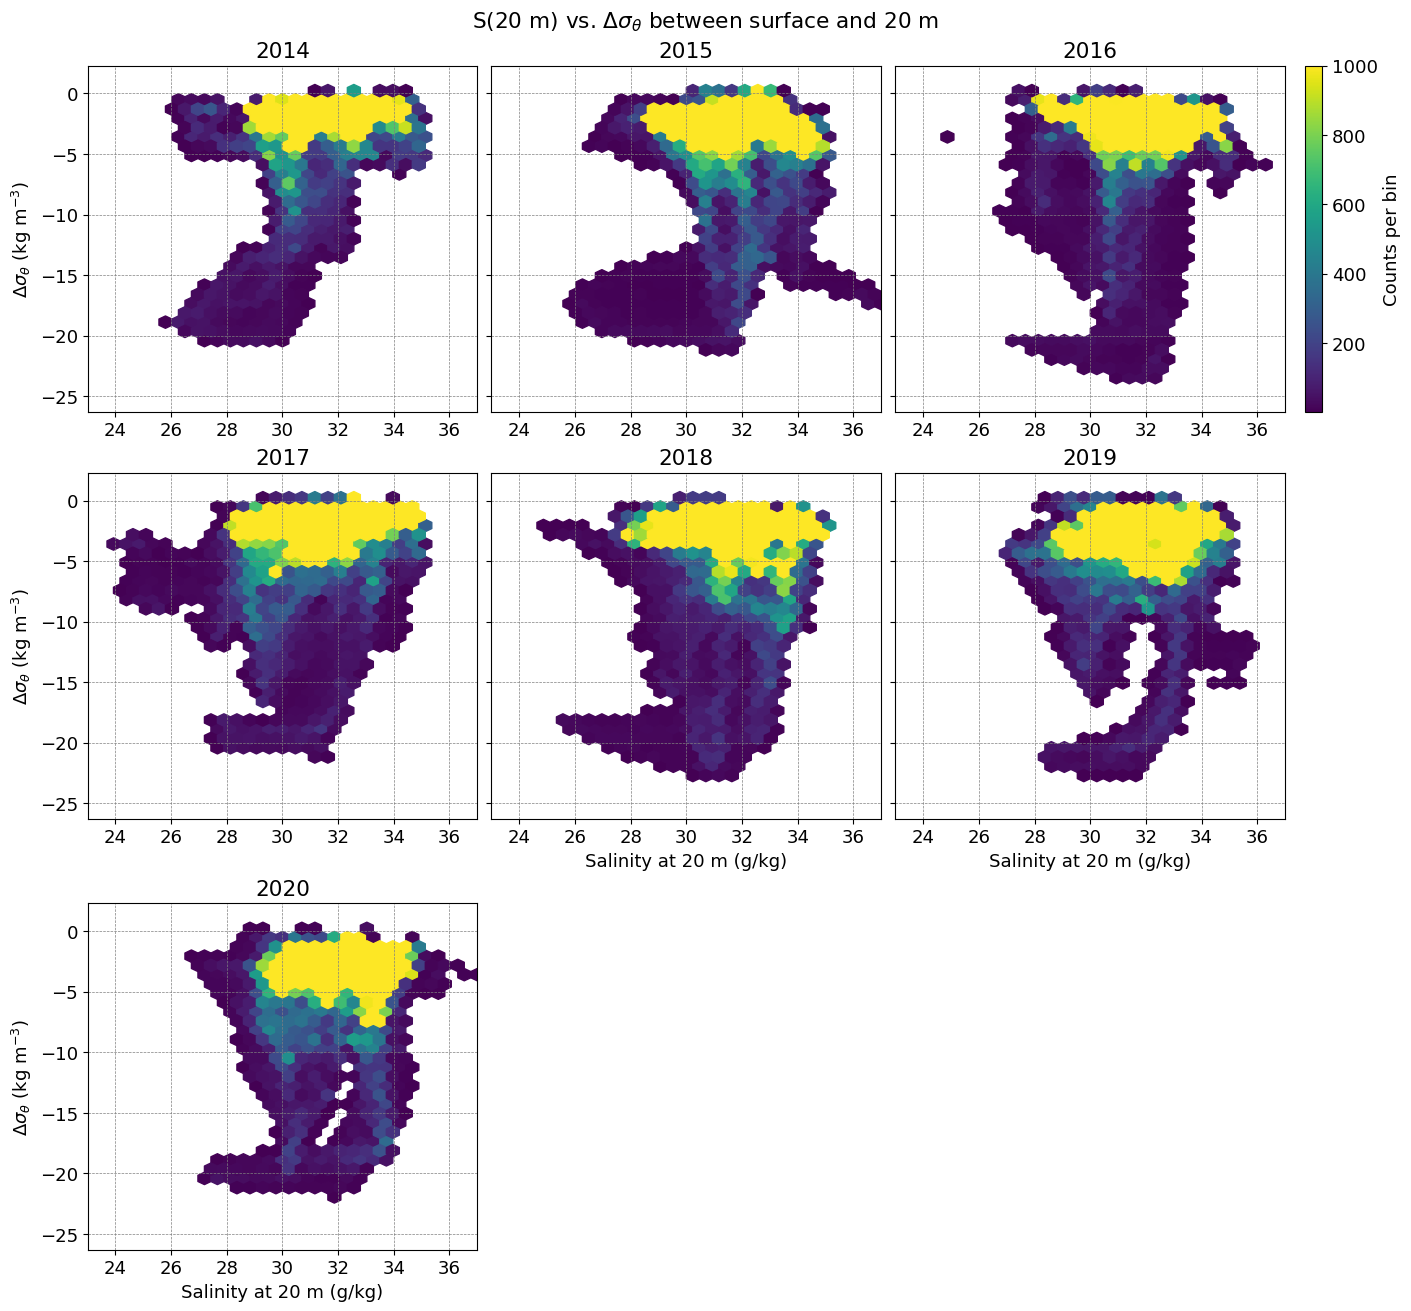

Time taken to plot: 0.0752 minutes


In [25]:
# Measure the time taken to plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6),(ax7,ax8,ax9)) = plt.subplots(3,3,figsize=[14,13], sharey=True, layout='constrained')

# difference in density between surface and 20 m (surf-20)
extent = [23,37,-25,1]

ax1.hexbin(salt_august_avg.isel(k=10,year=0),delta_sigma_20m.isel(year=0), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax2.hexbin(salt_august_avg.isel(k=10,year=1),delta_sigma_20m.isel(year=1), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
cbar_num = ax3.hexbin(salt_august_avg.isel(k=10,year=2),delta_sigma_20m.isel(year=2), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax4.hexbin(salt_august_avg.isel(k=10,year=3),delta_sigma_20m.isel(year=3), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax5.hexbin(salt_august_avg.isel(k=10,year=4),delta_sigma_20m.isel(year=4), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax6.hexbin(salt_august_avg.isel(k=10,year=5),delta_sigma_20m.isel(year=5), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax7.hexbin(salt_august_avg.isel(k=10,year=6),delta_sigma_20m.isel(year=6), gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)

ax1.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax4.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax7.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_num,ax=ax3)
cbar.ax.set_ylabel('Counts per bin');

for ax in (ax1,ax2,ax3,ax4,ax5,ax6,ax7):
    ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
    ax.set_xlim(23,37)
    ax.set_xlabel("")

ax7.set_xlabel("Salinity at 20 m (g/kg)")
ax5.set_xlabel("Salinity at 20 m (g/kg)")
ax6.set_xlabel("Salinity at 20 m (g/kg)")
    
# Turn off the axes we don't need
ax8.set_axis_off()
ax9.set_axis_off()

# titles
ax1.set_title(str(salt_august_avg.isel(year=0).year.values))
ax2.set_title(str(salt_august_avg.isel(year=1).year.values))
ax3.set_title(str(salt_august_avg.isel(year=2).year.values))
ax4.set_title(str(salt_august_avg.isel(year=3).year.values))
ax5.set_title(str(salt_august_avg.isel(year=4).year.values))
ax6.set_title(str(salt_august_avg.isel(year=5).year.values))
ax7.set_title(str(salt_august_avg.isel(year=6).year.values))

plt.suptitle(r'S(20 m) vs. $\Delta \sigma_{\theta}$ between surface and 20 m');

end_time = time.time()  # End timer

plt.show()

# Compute and display elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")

## Multiple correlation analysis

We should just do a multiple correlation analysis eg stratification = a * SSS + b * S(depth) + c * SST + d * T(depth). Over our Arctic Ocean domain, we'll find that a is largest ie explains the most variance, but perhaps b contributes a bit. And c and d might play a role in recent years in the summer when the water's been getting warm.

In [35]:
# define all vars
SSS = salt_august_avg.isel(k=0)
S_20m = salt_august_avg.isel(k=10)
SST = theta_august_avg.isel(k=0)
T_20m = theta_august_avg.isel(k=10)
strat = delta_sigma_20m

In [36]:
# look at shape
print(SSS.shape)
print(S_20m.shape)
print(SST.shape)
print(T_20m.shape)
print(strat.shape)

(7, 1080, 1800)
(7, 1080, 1800)
(7, 1080, 1800)
(7, 1080, 1800)
(7, 1080, 1800)


In [37]:
# see how correlated these terms are to one another

In [47]:
# First flatten 3D variables into 1D arrays
SSS_flat = SSS.values.flatten()
S_20m_flat = S_20m.values.flatten()
SST_flat = SST.values.flatten()
T_20m_flat = T_20m.values.flatten()
strat_flat = strat.values.flatten()

In [45]:
# Create a DataFrame for pairwise correlation
df = pd.DataFrame({
    "SSS": SSS_flat,
    "S_20m": S_20m_flat,
    "SST": SST_flat,
    "T_20m": T_20m_flat
})

In [46]:
# Drop rows with NaN values (e.g., land or missing data)
df = df.dropna()

# Compute pairwise correlations
correlation_matrix = df.corr()

# Display the correlation matrix
print("Pairwise Correlation Matrix:")
print(correlation_matrix)

Pairwise Correlation Matrix:
            SSS     S_20m       SST     T_20m
SSS    1.000000  0.452338 -0.153988 -0.099554
S_20m  0.452338  1.000000  0.049772  0.047262
SST   -0.153988  0.049772  1.000000  0.804500
T_20m -0.099554  0.047262  0.804500  1.000000


Going to drop `T_20m`

#### Run OLS analysis

In [50]:
import statsmodels.api as sm

In [74]:
# Create a data matrix (independent variables)
X = np.column_stack([SSS_flat, S_20m_flat, SST_flat])
X = sm.add_constant(X)  # Add intercept

# Fit regression model
model = sm.OLS(strat_flat, X, missing='drop')  # Handles NaN values
results = model.fit()

In [76]:
# Get coefficients
coefficients = results.params

print("Coefficients (a, b, c):", coefficients[1:])

Coefficients (a, b, c): [ 0.80086618 -0.80067484 -0.02746309]


In [77]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.775e+09
Date:                Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                        20:58:37   Log-Likelihood:             5.1778e+06
No. Observations:             3609641   AIC:                        -1.036e+07
Df Residuals:                 3609637   BIC:                        -1.036e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0634      0.001    -88.820      0.000      -0.065      -0.062
x1             0.8009   1.13e-05   7.11e+04      0.000       0.801       0.801
x2            -0.8007   2.54e-05  -3.15e+04      0.000      -0.801      -0.801
x3            -0.0275   1.51e-05  -1815.973      0.000      -0.027      -0.027
==============================================================================
Omnibus:                  2429712.081   Durbin-Watson:                   0.051
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         99015069.966
Skew:                           2.715   Prob(JB):                         0.00
Kurtosis:                      28.077   Cond. No.                     1.01e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.01e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Run OLS analysis for just SSS

### 20 m

In [64]:
strat_flat = delta_sigma_20m.values.flatten()

In [65]:
# Create a data matrix (independent variables)
X = SSS_flat
X = sm.add_constant(X)  # Add intercept

# Fit regression model
model = sm.OLS(strat_flat, X, missing='drop')  # Handles NaN values
results = model.fit()

In [66]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                 1.501e+07
Date:                Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                        20:50:15   Log-Likelihood:            -5.0312e+06
No. Observations:             3609641   AIC:                         1.006e+07
Df Residuals:                 3609639   BIC:                         1.006e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -20.8689      0.005  -4347.698      0.000     -20.878     -20.860
x1             0.6450      0.000   3874.564      0.000       0.645       0.645
==============================================================================
Omnibus:                   151290.678   Durbin-Watson:                   0.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           174658.750
Skew:                          -0.497   Prob(JB):                         0.00
Kurtosis:                       3.414   Cond. No.                         270.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 100 m

In [67]:
strat_flat = delta_sigma_100m.values.flatten()

In [68]:
# Create a data matrix (independent variables)
X = SSS_flat
X = sm.add_constant(X)  # Add intercept

# Fit regression model
model = sm.OLS(strat_flat, X, missing='drop')  # Handles NaN values
results = model.fit()

In [69]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                 2.002e+07
Date:                Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                        20:50:50   Log-Likelihood:            -2.3196e+06
No. Observations:             2859395   AIC:                         4.639e+06
Df Residuals:                 2859393   BIC:                         4.639e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -22.1157      0.004  -5285.834      0.000     -22.124     -22.107
x1             0.6422      0.000   4474.805      0.000       0.642       0.642
==============================================================================
Omnibus:                   152280.304   Durbin-Watson:                   0.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           177664.251
Skew:                          -0.602   Prob(JB):                         0.00
Kurtosis:                       3.200   Cond. No.                         379.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### stratification and S(20 m)

In [70]:
strat_flat = delta_sigma_20m.values.flatten()

In [71]:
# Create a data matrix (independent variables)
X = S_20m_flat
X = sm.add_constant(X)  # Add intercept

# Fit regression model
model = sm.OLS(strat_flat, X, missing='drop')  # Handles NaN values
results = model.fit()

In [72]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     790.8
Date:                Mon, 02 Dec 2024   Prob (F-statistic):          5.56e-174
Time:                        20:56:21   Log-Likelihood:            -7.9920e+06
No. Observations:             3609641   AIC:                         1.598e+07
Df Residuals:                 3609639   BIC:                         1.598e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.1446      0.027   -115.207      0.000      -3.198      -3.091
x1             0.0243      0.001     28.122      0.000       0.023       0.026
==============================================================================
Omnibus:                  3022082.204   Durbin-Watson:                   0.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         83614668.698
Skew:                          -4.004   Prob(JB):                         0.00
Kurtosis:                      25.177   Cond. No.                         741.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""